# CNNs for Object Detection – YOLO and Faster R-CNN (Pretrained)


## Learning Objectives

By the end of this lab, students should be able to:

- Understand object detection vs classification

- Run inference using:

  - YOLOv8

  - Faster R-CNN

- Compare one-stage vs two-stage detectors

- Visualize bounding boxes and confidence scores

## Setup

In [ ]:
# Install required libraries
!pip install ultralytics
# !pip install torchvision
# !pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.1 MB/s eta 0:00:00


In [ ]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms
from PIL import Image
from ultralytics import YOLO
from torchvision.transforms import ToPILImage
import matplotlib.patches as patches

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Load Dataset (Small Portion of VOC Dataset)

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="segmentation",
    download=True,
    transform=transform,
    target_transform=transform
)

# Small subset (5 images only)
subset_indices = list(range(5))
pet_subset = torch.utils.data.Subset(dataset, subset_indices)

len(pet_subset)

5

In [ ]:
def mask_to_bbox(mask):
    # Ensure mask is a 2D numpy array (H, W)
    # The mask from the dataset after ToTensor will be a torch.Tensor of shape (1, H, W)
    mask_np = np.array(mask.squeeze(0)) # Squeeze channel dimension if present, then convert to numpy

    # np.where returns (row_indices, col_indices) for a 2D array
    rows, cols = np.where(mask_np > 0)

    if len(rows) == 0:
        # No pet pixels found, return a default 'empty' bounding box
        return 0, 0, 0, 0

    y_min, x_min = np.min(rows), np.min(cols)
    y_max, x_max = np.max(rows), np.max(cols)

    return x_min, y_min, x_max, y_max

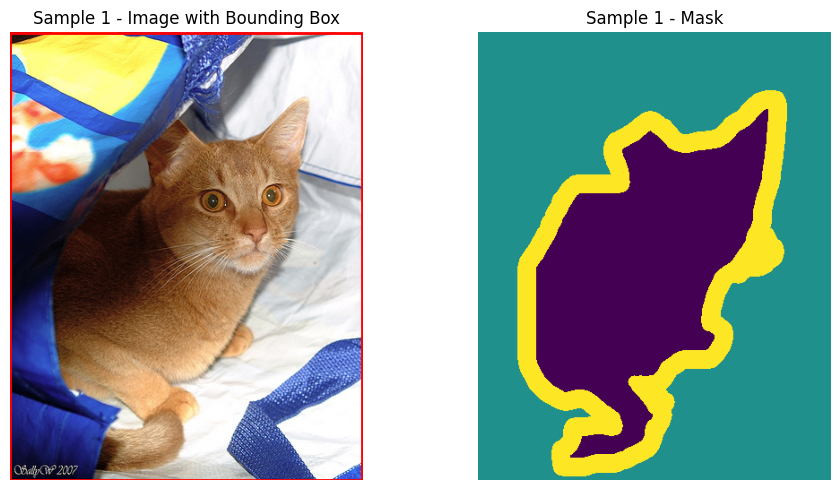

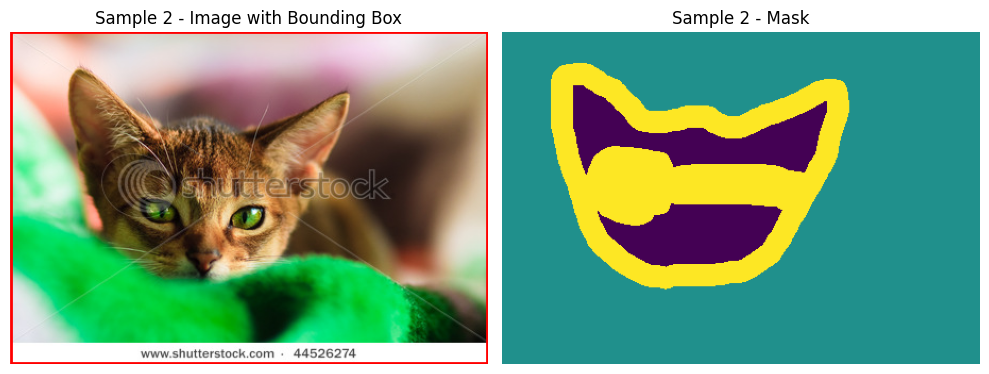

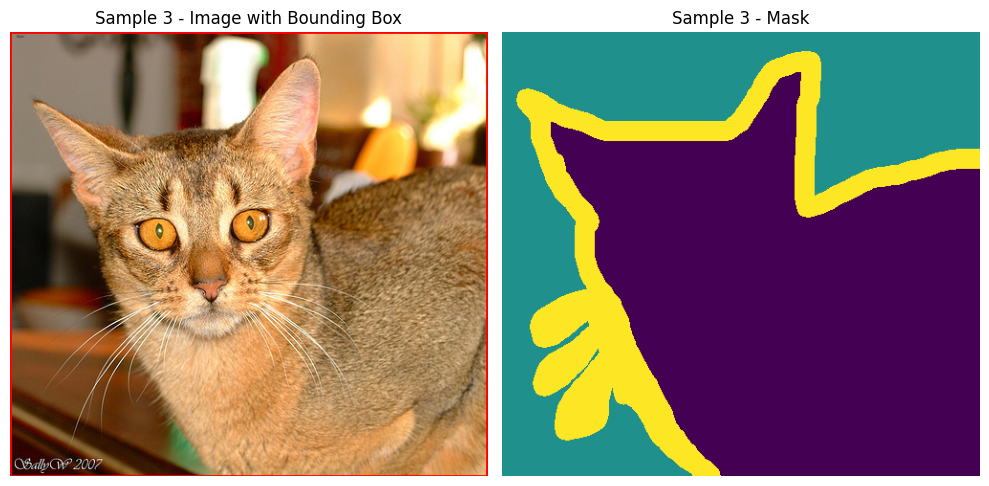

In [ ]:
num_samples_to_show = 3

for i in range(num_samples_to_show):
    img, mask = pet_subset[i]
    bbox = mask_to_bbox(mask)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Display original image with bounding box
    axes[0].imshow(img.permute(1, 2, 0))
    axes[0].set_title(f"Sample {i+1} - Image with Bounding Box")
    axes[0].axis("off")

    x1, y1, x2, y2 = bbox
    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )
    axes[0].add_patch(rect)

    # Display mask
    # Check if mask is a tensor and has 3 dimensions (C, H, W) before permuting
    # If it's a single channel mask (H, W), imshow handles it directly
    if isinstance(mask, torch.Tensor) and mask.ndim == 3 and mask.shape[0] in [1, 3]:
        axes[1].imshow(mask.permute(1, 2, 0).squeeze(-1) if mask.shape[0] == 1 else mask.permute(1, 2, 0))
    else:
        axes[1].imshow(mask)
    axes[1].set_title(f"Sample {i+1} - Mask")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

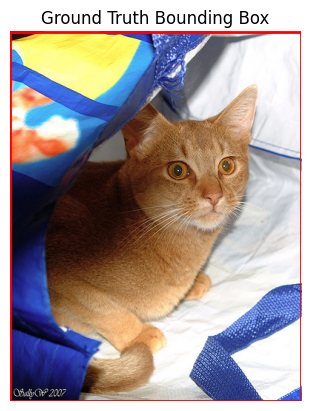

In [ ]:
img, mask = pet_subset[0]

bbox = mask_to_bbox(mask)

plt.imshow(img.permute(1,2,0))
plt.title("Ground Truth Bounding Box")
plt.axis("off")

import matplotlib.patches as patches

ax = plt.gca()
x1, y1, x2, y2 = bbox

rect = patches.Rectangle(
    (x1, y1),
    x2-x1,
    y2-y1,
    linewidth=2,
    edgecolor='red',
    facecolor='none'
)

ax.add_patch(rect)
plt.show()

## Loading the pretrained model

In [ ]:
model_yolo = YOLO("yolov8n.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
img_pil = ToPILImage()(img)
img_path = "pet_sample.jpg"
img_pil.save(img_path)


image 1/1 /content/pet_sample.jpg: 640x512 1 cat, 1 bed, 1 book, 73.3ms
Speed: 10.7ms preprocess, 73.3ms inference, 37.6ms postprocess per image at shape (1, 3, 640, 512)


(np.float64(-0.5), np.float64(393.5), np.float64(499.5), np.float64(-0.5))

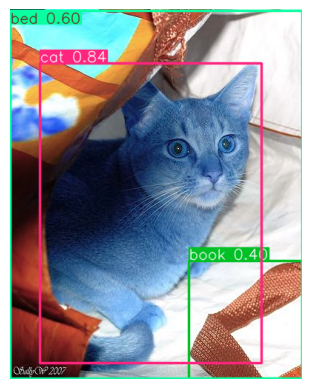

In [ ]:
results = model_yolo(img_path)

plt.imshow(results[0].plot())
plt.axis("off")

## Using pretrained R-CNN object detection model from torchvision to perform inference on an image.

In [ ]:
model_frcnn = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
model_frcnn.eval()

with torch.no_grad():
    prediction = model_frcnn([img])

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 128MB/s]


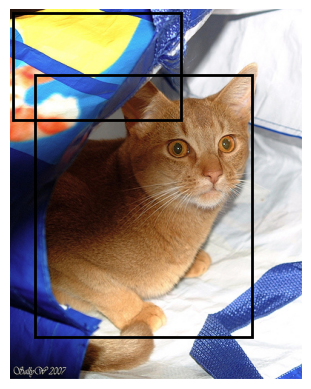

In [ ]:
boxes = prediction[0]['boxes']
scores = prediction[0]['scores']

plt.imshow(img.permute(1,2,0))
ax = plt.gca()

for i in range(len(boxes)):
    if scores[i] > 0.5:
        box = boxes[i].numpy()
        rect = plt.Rectangle(
            (box[0], box[1]),
            box[2]-box[0],
            box[3]-box[1],
            fill=False,
            linewidth=2
        )
        ax.add_patch(rect)

plt.axis("off")
plt.show()